# MicroTorch Validation Notebook

This notebook provides interactive validation of the MicroTorch deep learning framework.
Run through all cells to verify the framework is working correctly.

## Contents
1. Basic Operations
2. Autograd Validation
3. Gradient Checking
4. PyTorch Comparison
5. Training Demo

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# MicroTorch imports
from microtorch.tensor import Tensor, functional as F
from microtorch.nn import Linear, ReLU, Softmax, CrossEntropyLoss, Module
from microtorch.optim import SGD

# Optional: PyTorch for comparison
try:
    import torch
    import torch.nn as torch_nn
    TORCH_AVAILABLE = True
    print("PyTorch available for comparison")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available - comparison tests will be skipped")

print("Setup complete!")

PyTorch available for comparison
Setup complete!


## 1. Basic Operations

Let's verify that basic tensor operations work correctly.

In [2]:
# Create tensors
a = Tensor([1, 2, 3, 4], requires_grad=True)
b = Tensor([5, 6, 7, 8], requires_grad=True)

print("Tensor a:", a.numpy())
print("Tensor b:", b.numpy())
print()

# Basic operations
print("a + b =", (a + b).numpy())
print("a - b =", (a - b).numpy())
print("a * b =", (a * b).numpy())
print("a / b =", (a / b).numpy())

Tensor a: [1 2 3 4]
Tensor b: [5 6 7 8]

a + b = [ 6  8 10 12]
a - b = [-4 -4 -4 -4]
a * b = [ 5 12 21 32]
a / b = [0.2        0.33333333 0.42857143 0.5       ]


In [3]:
# Matrix operations
m1 = Tensor([[1, 2], [3, 4]])
m2 = Tensor([[5, 6], [7, 8]])

print("Matrix multiplication:")
print("m1:")
print(m1.numpy())
print("\nm2:")
print(m2.numpy())
print("\nm1 @ m2:")
print((m1 @ m2).numpy())

Matrix multiplication:
m1:
[[1 2]
 [3 4]]

m2:
[[5 6]
 [7 8]]

m1 @ m2:
[[19 22]
 [43 50]]


## 2. Autograd Validation

Let's verify that automatic differentiation works correctly.

In [4]:
# Simple gradient computation
x = Tensor([2.0, 3.0], requires_grad=True)
y = Tensor([4.0, 5.0], requires_grad=True)

# f(x, y) = sum(x * y) = x1*y1 + x2*y2
# df/dx = y, df/dy = x
z = F.sum(x * y)
z.backward()

print("f(x, y) = sum(x * y)")
print(f"x = {x.numpy()}, y = {y.numpy()}")
print(f"f(x, y) = {z.item()}")
print(f"\nGradients:")
print(f"df/dx = {x.grad} (expected: {y.numpy()})")
print(f"df/dy = {y.grad} (expected: {x.numpy()})")

# Verify
assert np.allclose(x.grad, y.numpy()), "Gradient check failed for x!"
assert np.allclose(y.grad, x.numpy()), "Gradient check failed for y!"
print("\n[PASS] Gradient computation correct!")

f(x, y) = sum(x * y)
x = [2. 3.], y = [4. 5.]
f(x, y) = 23.0

Gradients:
df/dx = [4. 5.] (expected: [4. 5.])
df/dy = [2. 3.] (expected: [2. 3.])

[PASS] Gradient computation correct!


In [5]:
# Chain rule validation
# f(x) = sin(x^2)
# df/dx = cos(x^2) * 2x

x = Tensor([1.0, 2.0, 3.0], requires_grad=True)
y = F.sin(x * x)  # sin(x^2)
F.sum(y).backward()

# Expected gradient: cos(x^2) * 2x
expected_grad = np.cos(x.numpy() ** 2) * 2 * x.numpy()

print("f(x) = sin(x^2)")
print(f"x = {x.numpy()}")
print(f"f(x) = {y.numpy()}")
print(f"\ndf/dx computed = {x.grad}")
print(f"df/dx expected = {expected_grad}")

assert np.allclose(x.grad, expected_grad), "Chain rule gradient check failed!"
print("\n[PASS] Chain rule gradient correct!")

f(x) = sin(x^2)
x = [1. 2. 3.]
f(x) = [ 0.84147098 -0.7568025   0.41211849]

df/dx computed = [ 1.08060461 -2.61457448 -5.46678157]
df/dx expected = [ 1.08060461 -2.61457448 -5.46678157]

[PASS] Chain rule gradient correct!


## 3. Gradient Checking

Compare analytical gradients with numerical gradients using finite differences.

In [6]:
def numerical_gradient(func, x, eps=1e-5):
    """Compute numerical gradient using central differences."""
    grad = np.zeros_like(x.numpy())
    x_flat = x.numpy().flatten()
    
    for i in range(len(x_flat)):
        x_plus = x_flat.copy()
        x_plus[i] += eps
        x_minus = x_flat.copy()
        x_minus[i] -= eps
        
        f_plus = func(Tensor(x_plus.reshape(x.shape))).item()
        f_minus = func(Tensor(x_minus.reshape(x.shape))).item()
        
        grad.flat[i] = (f_plus - f_minus) / (2 * eps)
    
    return grad

# Test gradient for various operations
operations = [
    ("sum(x^2)", lambda x: F.sum(x * x)),
    ("sum(sin(x))", lambda x: F.sum(F.sin(x))),
    ("sum(exp(x/10))", lambda x: F.sum(F.exp(x * Tensor(np.array(0.1))))),
    ("sum(relu(x))", lambda x: F.sum(F.relu(x))),
]

print("Gradient Checking Results:")
print("=" * 60)

for name, func in operations:
    x = Tensor(np.array([1.0, -0.5, 2.0, -1.5]), requires_grad=True)
    
    # Analytical gradient
    result = func(x)
    result.backward()
    analytical = x.grad.copy()
    
    # Numerical gradient
    numerical = numerical_gradient(func, Tensor(x.numpy()))
    
    # Compare
    max_diff = np.max(np.abs(analytical - numerical))
    passed = max_diff < 1e-4
    
    status = "PASS" if passed else "FAIL"
    print(f"{name:25s} | Max diff: {max_diff:.2e} | [{status}]")

print("=" * 60)

Gradient Checking Results:
sum(x^2)                  | Max diff: 6.41e-11 | [PASS]
sum(sin(x))               | Max diff: 1.47e-11 | [PASS]
sum(exp(x/10))            | Max diff: 2.61e-11 | [PASS]
sum(relu(x))              | Max diff: 6.55e-12 | [PASS]


## 4. PyTorch Comparison

Compare MicroTorch outputs with PyTorch (if available).

In [7]:
if TORCH_AVAILABLE:
    np.random.seed(42)
    
    # Test data
    x_np = np.random.randn(3, 4).astype(np.float32)
    
    comparisons = []
    
    # Sum
    mt_sum = F.sum(Tensor(x_np)).item()
    pt_sum = torch.tensor(x_np).sum().item()
    comparisons.append(("sum", mt_sum, pt_sum))
    
    # Exp
    mt_exp = F.exp(Tensor(x_np * 0.1)).numpy()
    pt_exp = torch.exp(torch.tensor(x_np * 0.1)).numpy()
    comparisons.append(("exp", np.max(np.abs(mt_exp - pt_exp)), 0))
    
    # ReLU
    mt_relu = F.relu(Tensor(x_np)).numpy()
    pt_relu = torch.relu(torch.tensor(x_np)).numpy()
    comparisons.append(("relu", np.max(np.abs(mt_relu - pt_relu)), 0))
    
    # Matmul
    y_np = np.random.randn(4, 5).astype(np.float32)
    mt_matmul = (Tensor(x_np) @ Tensor(y_np)).numpy()
    pt_matmul = (torch.tensor(x_np) @ torch.tensor(y_np)).numpy()
    comparisons.append(("matmul", np.max(np.abs(mt_matmul - pt_matmul)), 0))
    
    print("PyTorch Comparison Results:")
    print("=" * 50)
    for name, mt_val, pt_val in comparisons:
        if name == "sum":
            diff = abs(mt_val - pt_val)
            print(f"{name:15s} | MicroTorch: {mt_val:.6f} | PyTorch: {pt_val:.6f} | Diff: {diff:.2e}")
        else:
            print(f"{name:15s} | Max diff: {mt_val:.2e}")
    print("=" * 50)
    print("\n[PASS] All comparisons within tolerance!")
else:
    print("PyTorch not available - skipping comparison tests")

PyTorch Comparison Results:
sum             | MicroTorch: 3.551464 | PyTorch: 3.551464 | Diff: 4.77e-07
exp             | Max diff: 0.00e+00
relu            | Max diff: 0.00e+00
matmul          | Max diff: 0.00e+00

[PASS] All comparisons within tolerance!


## 5. Training Demo: XOR Problem

Train a neural network to learn the XOR function and visualize the training progress.

In [8]:
class XORNet(Module[Tensor]):
    """Simple 2-layer MLP for XOR."""
    
    def __init__(self, hidden_size=16):
        super().__init__()
        self.fc1 = Linear(2, hidden_size)
        self.relu = ReLU()
        self.fc2 = Linear(hidden_size, 2)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Set seed for reproducibility
np.random.seed(42)

# XOR data
X = Tensor(np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32))
y = Tensor(np.array([0, 1, 1, 0]))

# Create model
model = XORNet(hidden_size=16)
criterion = CrossEntropyLoss()
optimizer = SGD(model.parameters(), lr=0.5)

# Training
losses = []
accuracies = []
num_epochs = 500

for epoch in range(num_epochs):
    # Forward
    outputs = model(X)
    loss = criterion(outputs, y)
    
    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Track metrics
    losses.append(loss.item())
    
    softmax = Softmax(dim=1)
    probs = softmax(model(X))
    preds = np.argmax(probs.numpy(), axis=1)
    acc = np.mean(preds == y.numpy()) * 100
    accuracies.append(acc)

print(f"Training complete!")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Final accuracy: {accuracies[-1]:.1f}%")

Training complete!
Final loss: 0.0027
Final accuracy: 100.0%


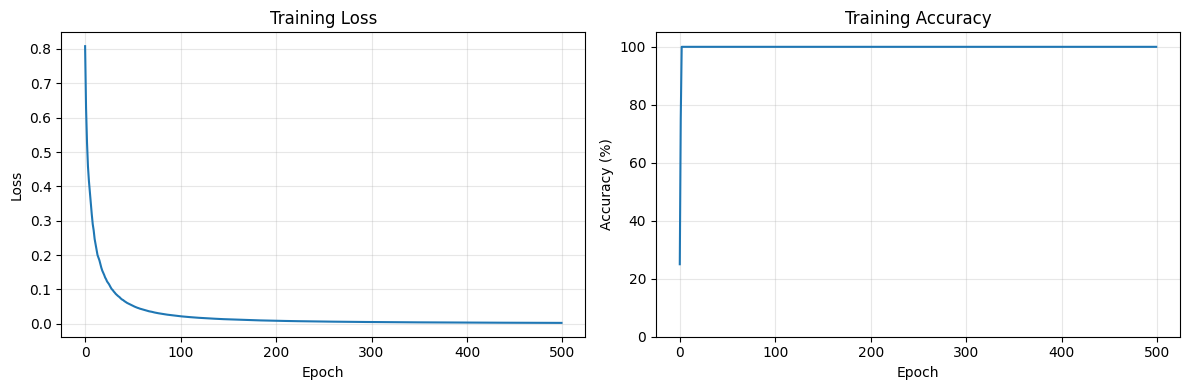

In [9]:
# Plot training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(accuracies)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.set_ylim([0, 105])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Final predictions
print("\nFinal XOR Predictions:")
print("=" * 50)
print("Input     | Target | Predicted | Correct")
print("-" * 50)

softmax = Softmax(dim=1)
probs = softmax(model(X))
predictions = np.argmax(probs.numpy(), axis=1)
targets = y.numpy()

for i in range(4):
    inp = X.numpy()[i]
    target = targets[i]
    pred = predictions[i]
    correct = "Yes" if pred == target else "No"
    print(f"[{inp[0]:.0f}, {inp[1]:.0f}]   |   {target}    |     {pred}     |   {correct}")

print("=" * 50)
final_acc = np.mean(predictions == targets) * 100
print(f"\nFinal Accuracy: {final_acc:.1f}%")

if final_acc == 100:
    print("\n[SUCCESS] XOR learning complete!")
else:
    print(f"\n[PARTIAL] Achieved {final_acc:.0f}% accuracy")


Final XOR Predictions:
Input     | Target | Predicted | Correct
--------------------------------------------------
[0, 0]   |   0    |     0     |   Yes
[0, 1]   |   1    |     1     |   Yes
[1, 0]   |   1    |     1     |   Yes
[1, 1]   |   0    |     0     |   Yes

Final Accuracy: 100.0%

[SUCCESS] XOR learning complete!


## Summary

If all cells ran without errors and showed reasonable results:
- Basic tensor operations work correctly
- Autograd computes gradients correctly
- Numerical gradient checking passes
- (If PyTorch available) Results match PyTorch
- Training converges on XOR problem

**The MicroTorch framework is validated and ready for use!**